<a href="https://colab.research.google.com/github/ritheshp-18/DEEP-LEARNING---24BAD098/blob/main/exp_2_dl_part_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training with activation: sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8018 - loss: 0.8698 - val_accuracy: 0.9093 - val_loss: 0.3485
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9164 - loss: 0.3034 - val_accuracy: 0.9319 - val_loss: 0.2414
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9340 - loss: 0.2290 - val_accuracy: 0.9426 - val_loss: 0.2047
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9461 - loss: 0.1866 - val_accuracy: 0.9503 - val_loss: 0.1733
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9543 - loss: 0.1575 - val_accuracy: 0.9569 - val_loss: 0.1516
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9613 - loss: 0.1337 - val_accuracy: 0.9590 - val_loss: 0.1398
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9669 - loss: 0.1160 - val_accuracy: 0.9622 - val_loss: 0.1291
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9714 - loss: 0.1006 - val_accuracy: 0.

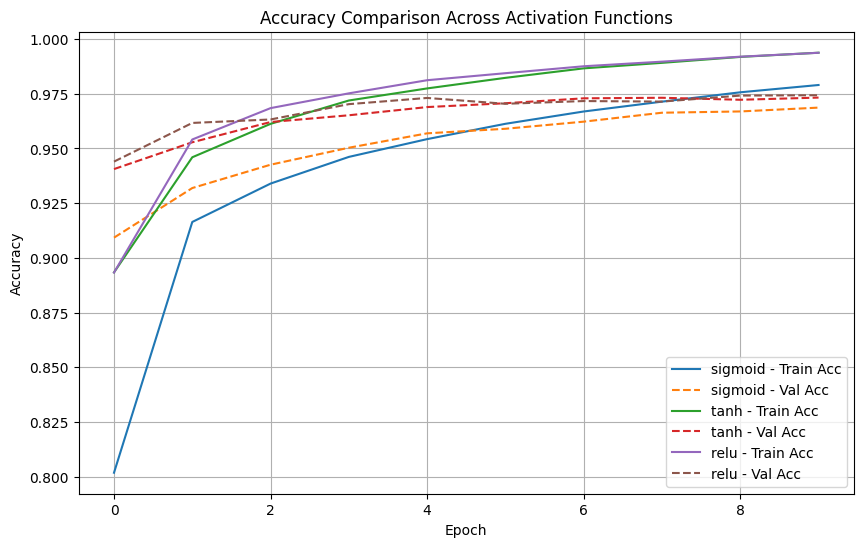

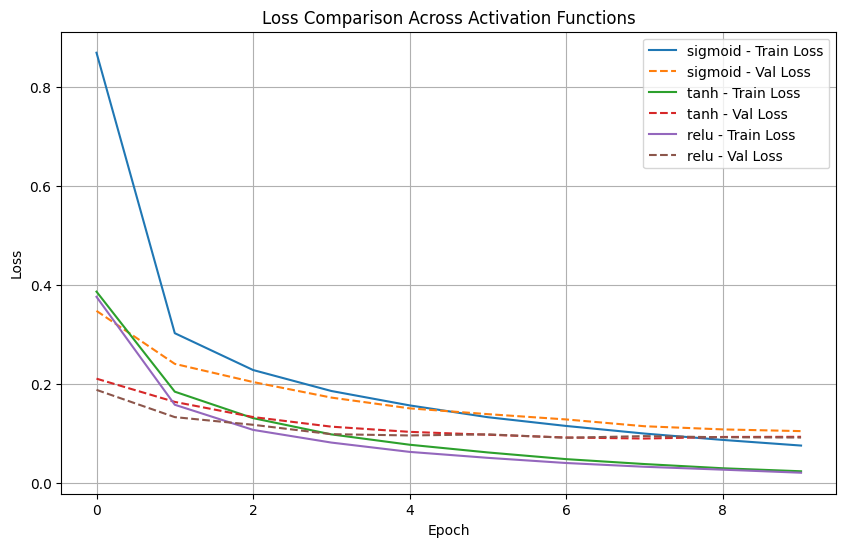

sigmoid: Final Val Accuracy = 0.9687, Final Val Loss = 0.1056
tanh: Final Val Accuracy = 0.9732, Final Val Loss = 0.0941
relu: Final Val Accuracy = 0.9743, Final Val Loss = 0.0926


In [1]:
# NAME : RITHESH P Roll No: 24BAD098
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_model(activation):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
    return model

activations = ['sigmoid', 'tanh', 'relu']
history_dict = {}

for act in activations:
    print(f"\nTraining with activation: {act}")
    model = build_model(act)
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                         validation_split=0.2, verbose=1)
    history_dict[act] = history

# Plot Training/Validation Accuracy
plt.figure(figsize=(10, 6))
for act in activations:
    plt.plot(history_dict[act].history['accuracy'], label=f'{act} - Train Acc')
    plt.plot(history_dict[act].history['val_accuracy'], '--', label=f'{act} - Val Acc')
plt.title('Accuracy Comparison Across Activation Functions')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('activation_accuracy_comparison.png')
plt.show()

# Plot Training/Validation Loss
plt.figure(figsize=(10, 6))
for act in activations:
    plt.plot(history_dict[act].history['loss'], label=f'{act} - Train Loss')
    plt.plot(history_dict[act].history['val_loss'], '--', label=f'{act} - Val Loss')
plt.title('Loss Comparison Across Activation Functions')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('activation_loss_comparison.png')
plt.show()

# Final results summary
for act in activations:
    final_acc = history_dict[act].history['val_accuracy'][-1]
    final_loss = history_dict[act].history['val_loss'][-1]
    print(f"{act}: Final Val Accuracy = {final_acc:.4f}, Final Val Loss = {final_loss:.4f}")